In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

In [24]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


step 2: EDA

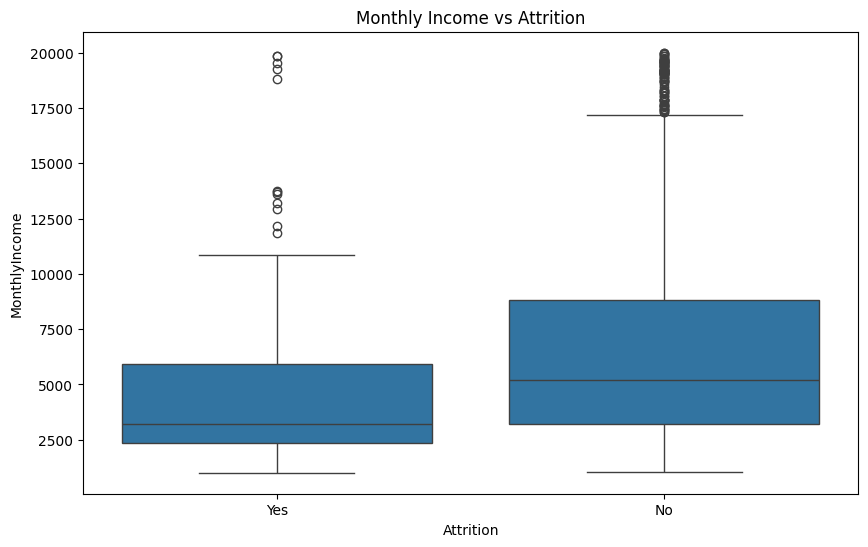

In [25]:
#plot: income vs Attrition
plt.figure(figsize=(10, 6))
sns.boxplot(x="Attrition",y="MonthlyIncome",data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

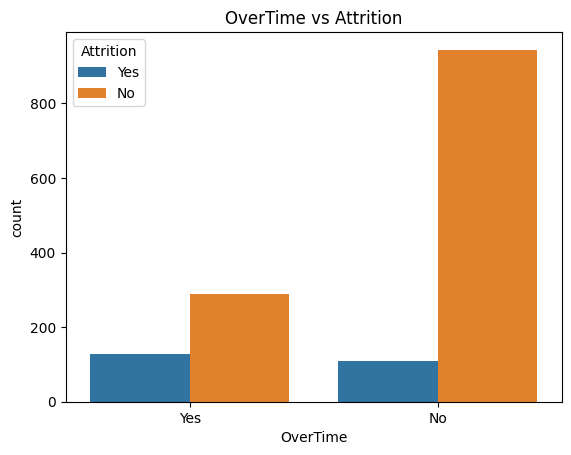

In [26]:
#impact on Overtime in Attrition
plt.Figure(figsize=(10, 6))
sns.countplot(x="OverTime",hue="Attrition",data=df)
plt.title("OverTime vs Attrition")
plt.show()

In [27]:
#step 3:Data preprocessing

In [28]:
df.drop(columns=["EmployeeNumber","EmployeeCount","Over18","StandardHours"], inplace=True)
df.shape

(1470, 31)

In [31]:
lb = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = lb.fit_transform(df[col])

x = df.drop("Attrition", axis=1)
y = df["Attrition"]

x_train, x_test, y_train,y_test = train_test_split(x, y, test_size=0.2,random_state=42)
#df["Attrition"] = lb.fit_transform(df["Attrition"])

step 4 Modeling and tunning(Hyperparameter)

In [34]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
#GrisSearchCV is computationally expensive
grid_search = GridSearchCV(rf,param_grid=param_grid,cv=5,scoring="f1")
grid_search.fit(x_train,y_train)
print("Best Parameters:",grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


step 5:Model Evaluate

In [36]:
best_model = grid_search.best_estimator_
predictions = best_model.predict(x_test)

print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294

[[253   2]
 [ 35   4]]


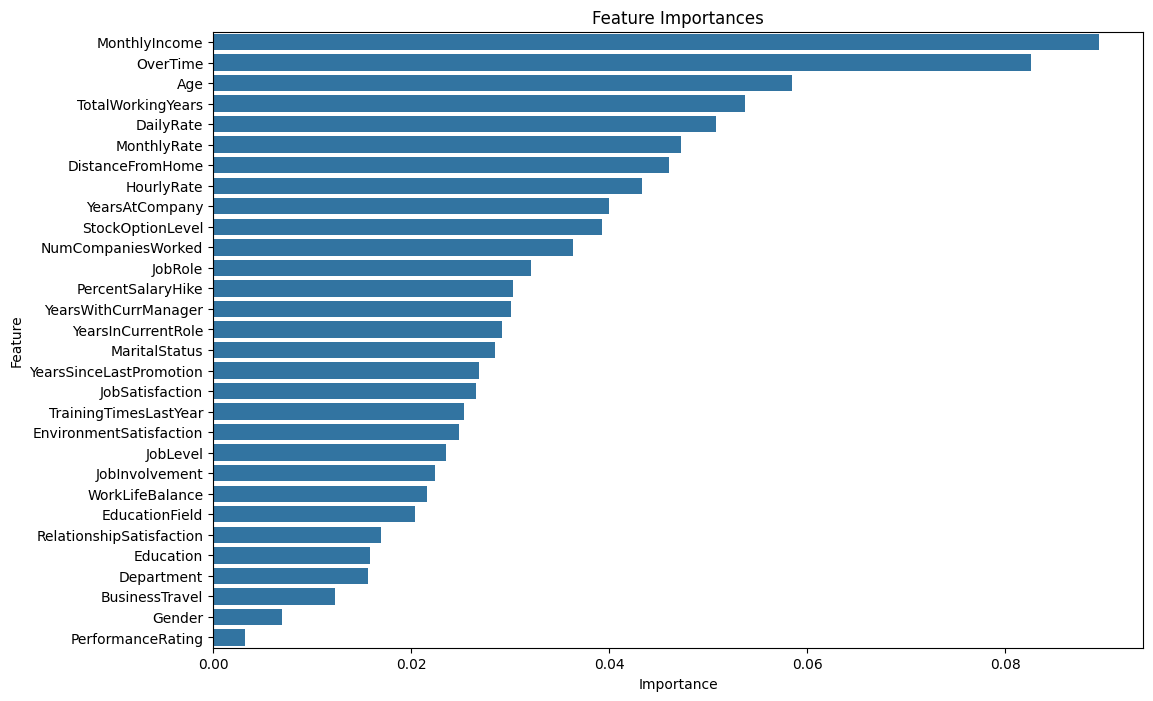

In [ ]:
importances = pd.DataFrame({
    "Feature": x.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by= "Importance",ascending= False)
plt.figure(figsize=(12, 8))
sns.barplot(x="Importance",y="Feature",data = importances)
plt.title("Feature Importances")ch
plt.show()